# Segmentacion

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [3]:
file_path = 'for_Holt.xlsx'
excel_data = pd.ExcelFile(file_path)

sheet_names = excel_data.sheet_names
sheet_names

['Sheet1']

In [4]:
data = excel_data.parse('Sheet1')

In [5]:
department_summary = data.groupby('Codigo_Dpto')['Titulo_Curso'].nunique().reset_index()
department_summary.columns = ['Codigo_Dpto', 'Unique_Courses_Count']

department_summary.sort_values(by='Unique_Courses_Count', ascending=False).head(10)


,Codigo_Dpto,Unique_Courses_Count
25,52,153
30,77,131
24,51,91
17,42,81
23,50,80
22,49,79
3,14,75
27,61,58
4,15,55
18,45,54


In [ ]:
spanish_stop_words = [
    'de', 'la', 'y', 'el', 'en', 'a', 'que', 'los', 'del', 'se', 'las', 'por', 'un', 'con', 
    'para', 'su', 'es', 'una', 'al', 'lo', 'como', 'más', 'o', 'sus', 'pero', 'le', 'ha', 'me', 
    'si', 'sin', 'sobre', 'este', 'ya', 'entre', 'cuando', 'todo', 'esta', 'ser', 'son', 'dos', 
    'también', 'fue', 'había', 'era', 'muy', 'hasta', 'desde', 'nos', 'durante', 'uno', 'ni', 'contra', 
    'ese', 'eso', 'mí', 'qué', 'otro', 'él', 'cual', 'poco', 'mi', 'tú', 'te', 'ti', 'no', 'sí', 'cada'
]

course_titles = data['Titulo_Curso'].astype(str)

vectorizer = TfidfVectorizer(stop_words=spanish_stop_words)
X = vectorizer.fit_transform(course_titles)

num_clusters = 50
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

cluster_samples = data.groupby('Cluster')['Titulo_Curso'].apply(lambda x: x.sample(min(len(x), 5))).reset_index()
cluster_samples.head(20)

,Cluster,level_1,Titulo_Curso
0,0,10938,FUNDAMENTOS DE MERCADEO
1,0,10549,FUNDAMENTOS DE CONTROL INTERNO
2,0,15758,FUNDAMENTOS DE MERCADEO
3,0,5713,FUNDAMENTOS DE ESTADISTICA
4,0,9440,FUNDAMENTOS DE PUBLICIDAD
5,1,12065,PSICOLOGÍA COMUNITARIA
6,1,5402,DESARROLLO SOCIOAFECTIVO
7,1,15347,STRATEGIC MAGEMENT
8,1,982,CIRCUITOS I
9,1,9881,ECUAC. DIFERENCIALES PARCIALES


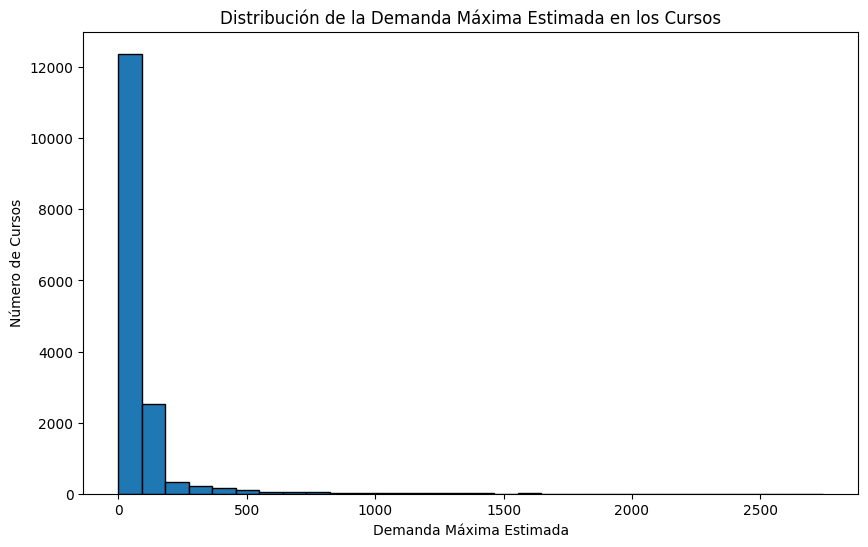

,Demand_Segment,Course_Count
0,bajo,7474
1,Medio,4407
2,Alto,2852
3,Muy Alto,340


In [14]:
plt.figure(figsize=(10, 6))
plt.hist(data['Demanda_Max_Estimada'], bins=30, edgecolor='k')
plt.title("Distribución de la Demanda Máxima Estimada en los Cursos")
plt.xlabel("Demanda Máxima Estimada")
plt.ylabel("Número de Cursos")
plt.show()

data['Demand_Segment'] = pd.cut(
    data['Demanda_Max_Estimada'], 
    bins=[0, 40, 100, 500, 2000], 
    labels=['bajo', 'Medio', 'Alto', 'Muy Alto']
)

# Displaying the counts of each segment to understand the distribution
demand_segment_counts = data['Demand_Segment'].value_counts().reset_index()
demand_segment_counts.columns = ['Demand_Segment', 'Course_Count']
demand_segment_counts

In [ ]:
very_high_demand_courses = data[data['Demand_Segment'] == 'Muy Alto']

top_demand_courses = very_high_demand_courses.sort_values(by='Demanda_Max_Estimada', ascending=False)

top_demand_courses.head(10)


,Periodo,Codigo_Dpto,Titulo_Curso,Num_Periodos_Ant,Matrícula_Estimada_Historica,Proyectados_Actual_(S),Meta_Nuevos,Demanda_Max_Estimada,Nro_Grupos_40,Nro_Grupos_30,Nro_Grupos_25,Cluster,Demand_Segment
14449,202410,48,ELECTIVA CIENCIAS SOCIALES,0,0,500,0,500,12.425,0.0,0.000000,5,Alto
10307,202210,13,INTRODUCCION A LA ECONOMIA,17,497,411,75,497,12.000,0.0,1.000000,6,Alto
466,201710,29,SOLUCIONES COMP. A PROB.EN ING,8,301,497,0,497,12.000,0.0,1.000000,1,Alto
9704,202130,26,ANÁLISIS DE DATOS EN INGEN I,13,496,325,0,496,12.000,0.0,1.000000,1,Alto
4680,201910,61,CALCULO II,10,495,362,0,495,12.000,0.0,1.000000,5,Alto
6778,202010,61,ELECTIVA BASICA PROFESIONAL,0,0,494,0,494,12.000,0.0,1.000000,42,Alto
1573,201730,77,EXIGENCIA INGLES I,6,494,348,0,494,0.000,0.0,22.454545,30,Alto
643,201710,61,CALCULO II,8,303,493,0,493,12.000,0.0,0.000000,5,Alto
12713,202310,77,EXIGENCIA INGLES V,11,492,390,0,492,0.000,0.0,22.000000,30,Alto
8678,202110,29,SOLUCIONES COMP. A PROB.EN ING,12,492,387,0,492,12.000,0.0,0.000000,1,Alto
